# Results Notebook

This Notebook contains the code for generating all figures and tables in the paper, using raw results from the experimaestro workspace.

# Imports and Utils

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# use ACM style

FONT_SIZE = 14
fig_dir = Path("./local/figures/mice")
# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
# 1. Configure Matplotlib for ACM Style
plt.rcParams.update(
    {
        "text.usetex": False,  # Set to True if you have LaTeX installed on your system
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
        "font.size": 10,  # Standard ACM body text size is ~9-10pt
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)
plt.style.use("ggplot")

xps_root = Path.home() / "experiments" / "JZ"
xps_root = Path.home() / "code" / "experiments" / "JZ"


def get_last_xp(xp_id, force_date=None, verbose=True) -> str:
    dates = sorted(list((xps_root / xp_id).glob("*")))
    if verbose: print(f"Found dates for {xp_id}: {[d.name for d in dates]}")

    # parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            if verbose: print(f"Using forced date for {xp_id}: {forced_date_path.name}")
            return forced_date_path
        else:
            if verbose: print(f"Forced date {force_date} not found for xp {xp_id}")

    dates = [d for d in dates if re.match(r"\d+_\d+", d.name)]

    last = "" 
    # last = max(dates, key=lambda d: d.name)
    for date in dates[::-1]:
        if (xps_root / xp_id / date / "results" / "results.csv").exists():
            last = date
            break


    if not last:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        last = "dry-run"

    return xps_root / xp_id / last


def get_results(xp_path, verbose=True) -> pd.DataFrame:
    path = xp_path / "results"
    csv_files = list(path.glob("results.csv"))

    if len(csv_files):
        return pd.read_csv(csv_files[0])
    else:
        raise ValueError(f"no csv files found in {path}")


def process_results(results) -> pd.DataFrame:
    # labels1 = results.iloc[0]
    if "tag" in list(results.columns)[-1]:
        print("V1 xp -> Rerun to get new df format !")
        labels1 = results.iloc[0]
        labels2 = results.iloc[1]
        results = results.iloc[3:]
    else:
        labels1 = [l1.split('.')[0] for l1 in results.columns]
        labels2 = results.iloc[0]
        results = results.iloc[2:]

    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    
    labels[0] = "dataset"
    results.columns = labels
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    #Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results


def get_aggregated_stats(results, group_cols, metrics):
    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f"{m}_mean", f"{m}_var"])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors="coerce")

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f"{m}_mean"] = f"{m}_Grand_Mean"
        rename_dict[f"{m}_var"] = f"{m}_Average_Var"

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)

    return aggregated_stats
    # Add experiment label


def get_aggregated_df(df, datasets, name):
    """
    Returns a NEW DataFrame with aggregated means for specific datasets.
    Does not modify the original df.
    """
    # 1. Identify metric columns and metadata columns
    metric_cols = df.filter(regex="(?i)mean|var").columns.tolist()
    # Metadata columns are everything EXCEPT the metrics and the dataset name
    metadata_cols = [c for c in df.columns if c not in metric_cols and c != "dataset"]

    # 2. Filter rows for the specified datasets
    subset = df[df["dataset"].isin(datasets)].copy()
    subset[metric_cols] = subset[metric_cols].apply(pd.to_numeric, errors="coerce")

    # 3. Group by ALL metadata columns to preserve them
    # This keeps 'base', 'loss', 'scorer', 'arch', etc. intact
    new_df = subset.groupby(metadata_cols, as_index=False)[metric_cols].mean()

    # 4. Assign the new dataset aggregate name
    new_df["dataset"] = name

    # Reorder for readability: dataset first, then metadata, then metrics
    cols = ["dataset"] + metadata_cols + metric_cols
    return new_df[cols]

from dataclasses import dataclass

@dataclass
class ModelResults:
    name: str

    path: Path
    """path to the model directory inf HF format"""

    results: pd.DataFrame = None
    """Results dataframe"""

    benchmark: dict = None
    """Performance benchmark"""

    benchmark_precompute: dict = None
    """Performance benchmark"""

def get_models(xp_path) -> list:
    path = xp_path / "results" / "models"
    #list directory and find csv files
    models = []

    model_dirs = [d for d in path.glob("*") if d.is_dir()]
    print(f"Found model directories in {path}: {[d.name for d in model_dirs]}")

    for model_dir in model_dirs:   
        csv_file = model_dir / "results.csv"
        if not csv_file.exists():
            print(f"Expected csv file not found in {model_dir}")
            continue
        else:
            models.append(
                ModelResults(
                    name=model_dir.name,
                    path=model_dir,
                    results=pd.read_csv(csv_file)
                )
            )
    return models


print(f"found xps in {xps_root}")
all_xps = list(xps_root.glob("*"))
for xp in sorted(all_xps):
    print(f"- {xp.name}")

found xps in /Users/victor/code/experiments/JZ
- RankDistiLLMNeg_base
- RankDistiLLMNeg_mini
- baseline_MiniLM_CE
- baseline_mores
- baseline_prettr_miniLM_l8
- baseline_small_CE
- baseline_small_CE_withruns
- baselines_base
- colbertNeg_base
- colbertNeg_infoNCE_precision
- colbertNeg_mini
- comparison_precision
- core_base
- core_base_deberta
- core_base_deberta_top100
- core_base_ettin
- core_base_ettin_1b
- core_base_ettin_1b_bs=16
- core_base_ettin_scaling
- core_base_ettin_scaling_except_1b
- core_base_paper
- core_mini
- core_mini_debug
- cross_scorer_evaluation
- cross_scorer_evaluation_debug
- debug_CE_training
- debug_mice_plaid
- debug_mice_training
- eval_masked_step0
- eval_scorer_bm25_top1000
- eval_scorer_debug
- eval_scorer_top100
- eval_scorer_top1000
- hyperparams_search_contrastive
- local_model_evaluation
- reproduction_RankDistiLLM
- train_mice_bert_l4+3
- train_mice_bert_l48+3
- train_mice_electra_l48+3
- train_mice_ettin150-l12+3
- train_mice_ettin17_lX+3
- train

### Labeling

In [2]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

ignore_losses = ["infoNCE_norm_size=True"]

/Users/victor/code/projects/cross-encoders/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Main Figures

## Mice-$\ell$ Y+X

### Loading

In [105]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_l4+X": r"Mice MiniLM-$\ell$4+X",
    # "train_mice_ettin_17m-l3+X": r"Mice Ettin-17m-$\ell$3+X", # don't use it - too small
    "train_mice_ettin_32m-l6+X": r"Mice Ettin-32m-$\ell$6+X",
    "train_mice_ettin_68m-l6+X": r"Mice Ettin-68m-$\ell$6+X",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/experiments/JZ/train_mice_miniLM_l4+X: []
No valid dates found for xp /Users/victor/experiments/JZ/train_mice_miniLM_l4+X, returning dry-run
Using xp path: /Users/victor/experiments/JZ/train_mice_miniLM_l4+X/dry-run


ValueError: no csv files found in /Users/victor/experiments/JZ/train_mice_miniLM_l4+X/dry-run/results

### Plotting

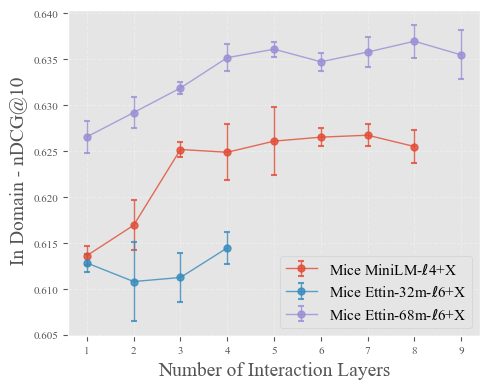

In [ ]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
y_key = "n_interaction_layers"
figsize=(5, 4)
# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=figsize)
    max_y = 1
    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df[y_key] = pd.to_numeric(df[y_key], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df[y_key].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        max_y = max(max_y, int(max(df[y_key].unique())))
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_interaction_layers and compute aggregated statistics
        grouped = dataset_df.groupby(y_key, dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values(y_key)

        ax.errorbar(
            grouped[y_key],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=5,
            linewidth=1,
            capsize=2,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]}"
        )

    # Formatting
    ax.set_xlabel("Number of Interaction Layers", fontsize=FONT_SIZE, fontweight="normal")
    ax.set_ylabel(f" {dataset_name} - nDCG@10", fontsize=FONT_SIZE, fontweight="normal")
    # ax.set_title(f"{metric} vs Interaction Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=FONT_SIZE-3)
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_InteractionLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
    # print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    # display(grouped)

## Mice X+3

### Loading

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Mice MiniLM-lX+3",
    "train_mice_miniLM_lX+3_bias": "Mice MiniLM-lX+3 Lex",
    # "train_mice_ettin68_lX+3": "Mice Ettin-68m-lX+3",
    # "train_mice_ettin32_lX+3": "Mice Ettin-32m-lX+3",
    # "train_mice_ettin17_lX+3": "Mice Ettin-17m-lX+3", #don't use it - too small
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', '20260515_093820', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3/20260513_093201
V1 xp -> Rerun to get new df format !
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
3,In Domain,0.728078,0.000001,0.822467,1.366335e-05,0.558767,6.601004e-06,0.557944,1.067045e-06,microsoft/MiniLM-L12-H384-uncased,bm25,0
4,In Domain,0.737978,0.000020,0.826256,2.223799e-06,0.583822,9.971361e-06,0.580033,4.407645e-06,microsoft/MiniLM-L12-H384-uncased,bm25,1
5,In Domain,0.754122,0.000004,0.840767,6.300482e-07,0.601944,1.107792e-05,0.595111,7.071646e-06,microsoft/MiniLM-L12-H384-uncased,bm25,2
6,In Domain,0.758422,0.000009,0.839556,1.444606e-05,0.613967,1.181150e-06,0.603267,1.877712e-07,microsoft/MiniLM-L12-H384-uncased,bm25,3
7,In Domain,0.764144,0.000004,0.844133,1.386999e-05,0.625155,6.781769e-07,0.611256,5.747773e-07,microsoft/MiniLM-L12-H384-uncased,bm25,4


Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_bias: ['20260519_131836', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_bias/20260519_131836
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_contextualization_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,0.0,0.721033,9.634420e-07,0.819445,3.433795e-06,0.559789,0.000006,0.555433,0.000002
3,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,1.0,0.748622,3.621618e-05,0.832378,1.518911e-05,0.589622,0.000014,0.585822,0.000001
4,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,2.0,0.748433,3.444382e-06,0.834567,7.511455e-07,0.598622,0.000013,0.591856,0.000002
5,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,3.0,0.752989,2.256473e-05,0.838478,1.638050e-06,0.616789,0.000002,0.605067,0.000011
6,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,4.0,0.760622,7.318092e-06,0.840889,6.480542e-08,0.622500,0.000003,0.610922,0.000004


### Plotting


Aggregated nDCG@10 Statistics by Contextualization Layers (In Domain):


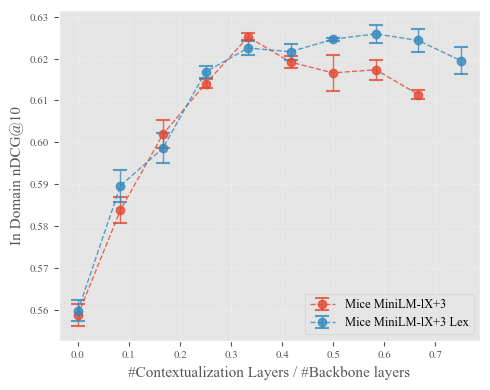

In [ ]:
from format import backbone_nlayers
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
figsize=(5, 4)

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=figsize)

    for xp, df in xp_dfs.items():
        base = df["base"].iloc[0]
        base_nlayers = backbone_nlayers.get(base,0)
        if not base_nlayers:
            print(f"Warning: Backbone {base} not found in backbone_nlayers mapping. Skipping normalization for this xp.")   
            continue
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")
        ys = grouped["mean_nDCG"].values
        xs = grouped["n_contextualization_layers"].values
        xs_norm = xs / base_nlayers
        ax.errorbar(
            x=xs_norm,
            y=ys,
            yerr=grouped["std_nDCG"],
            fmt="o--",
            markersize=6,
            linewidth=1,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]}"
        )

    # Formatting
    ax.set_xlabel("#Contextualization Layers / #Backbone layers", fontsize=11, fontweight="normal")
    ax.set_ylabel(f"{dataset_name} nDCG@10", fontsize=11, fontweight="normal")
    # ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
        # display(grouped)

# Table Mice Results


In [ ]:
# Main table
import pandas as pd

# Configuration
metric = "nDCG@10"

datasets_to_keep = aggregations["In Domain"] + aggregations["BEIR13"] + ["In Domain", "BEIR13"]

xps = {
    # baselines
    "baseline_small_CE": "Baseline",
    "baseline_mores": "Mores-$\\ell$10-d12+2",
    "baseline_prettr_miniLM_l8": "preTTR-$\\ell$8+4",
    # Mice Models
    # MiniLM
    "train_mice_miniLM_l4": "Mice-$\\ell$4+3",
    "train_mice_miniLM_l8+3": "Mice-$\\ell$8+3",
    "train_mice_miniLM_l8+3_bias": "Mice-$\\ell$8+3+Lex",
    # Ettin
    "train_mice_ettin_68m": "Mice-$\\ell$8+3",
    "train_mice_ettin_32m": "Mice-$\\ell$8+3",
    "train_mice_ettin_17m": "Mice-$\\ell$3+3",
    # "train_mice_ettin_150m": "test",
}
xp_models = {}
xp_dfs = {}

## Loading

In [ ]:

for xp in xps.keys():
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"\nxp path: {xp_path}")

    df = process_results(get_results(xp_path, verbose=False))
    datasets = df["dataset"].unique()
    backbones = list(df['base'].unique())
    print(f" - {len(datasets)} unique datasets : {list(datasets)}")
    print(f" - {len(backbones)} unique backbones : {backbones}")

    xp_dfs[xp] = df
    xp_models[xp] = get_models(xp_path)

Found dates for /Users/victor/code/experiments/JZ/baseline_small_CE: ['.DS_Store', '20260428_093714', '20260428_185727', '20260429_150025', '20260430_112724', '20260430_113205', '20260430_121822', '20260504_182428', '20260511_181552', '20260512_220506', '20260513_085602', '20260514_145145', '20260514_145549', '20260515_083354', 'current', 'dry-run', 'lock']

xp path: /Users/victor/code/experiments/JZ/baseline_small_CE/20260515_083354
 - 27 unique datasets : ['BEIR13', 'In Domain', 'Lotte-S', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid']
 - 5 unique backbones : ['jhu-clsp/ettin-encoder-17m', 'jhu-clsp/ettin-encoder-32m', 'jhu-clsp/ettin-encoder-68m', 'microsoft/MiniLM-L12-H384-uncased', nan]
Found model directories in /Users/victor/

## Processing

### Flops

In [ ]:
from flops import compute_flops_mice, get_transformer_params, compute_flops_prettr
from xpm_torch.huggingface import TorchHFHub

seq_len = 512

xp_flops = {}
for xp, models in xp_models.items():
    if not len(models):
        print(f"No models found for xp {xp}, skipping FLOPs computation for this xp.")
        continue
    if len(models) > 1:
        print(f"Several models found for xp {xp}, skipping FLOPs computation for this xp.")
        continue
    model = models[0]
    loader = TorchHFHub.pretrained_loader(model.path, as_instance=False)
    model_cfg = loader.model

    model_class= type(model_cfg).__name__.lower()
    if "mice" in model_class:
        hf_id = model_cfg.hf_id
        d, d_ff, nlayers = get_transformer_params(hf_id)
        model_flops, baseline_flops = compute_flops_mice(
                model_cfg, d, d_ff, nlayers, seq_len=seq_len, query_len=32
            )
    elif "prettr" in model_class:
        hf_id = model_cfg.encoder.config.hf_id
        d, d_ff, nlayers = get_transformer_params(hf_id)
        model_flops, baseline_flops = compute_flops_prettr(
            model_cfg.join_layer,
            d,
            d_ff,
            nlayers,
            seq_len=seq_len,
            query_len=32
        )
    else:
        print(f"Unknown model class {model_class} for model {model.name}, skipping FLOPs computation for this model.")
        hf_id = None
        model_flops, baseline_flops = 0, 1

    xp_flops[xp] = {
        "model_name": model.name,
        "hf_id": hf_id,
        "model_flops": model_flops,
        "baseline_flops": baseline_flops,
        "frac_baseline": model_flops / baseline_flops if baseline_flops != 0 else 0
    }
    
print("\nMICE FLOPs Results:")
display(pd.DataFrame(xp_flops).T)


config.json not found in /Users/victor/code/experiments/JZ/baseline_mores/20260519_145125/results/models/Mice-l10-d12+2-MiniLM-L12


No models found for xp baseline_small_CE, skipping FLOPs computation for this xp.


INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/MiniLM-L12-H384-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/MiniLM-L12-H384-uncased/44acabbec0ef496f6dbc93adadea57f376b7c0ec/config.json "HTTP/1.1 200 OK"
INFO:root:Cross-Attention Layer FLOPs: 0.56 GFLOPs, Attention FLOPs: 0.03 GFLOPs
INFO:root:Cross-Attention Layer FLOPs: 0.56 GFLOPs, Attention FLOPs: 0.03 GFLOPs
config.json not found in /Users/victor/code/experiments/JZ/baseline_prettr_miniLM_l8/20260519_144845/results/models/PreTTR-j8-MiniLM-L12
INFO:httpx:HTTP Request: HEAD https://huggingface.co/microsoft/MiniLM-L12-H384-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/MiniLM-L12-H384-uncased/44acabbec0ef496f6dbc93adadea57f376b7c0ec/config.json "HTTP/1.1 200 OK"
config.json not found in /Users/victor/code


MICE FLOPs Results:


,model_name,hf_id,model_flops,baseline_flops,frac_baseline
baseline_mores,Mice-l10-d12+2-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,27003979776.0,26575110144.0,1.016138
baseline_prettr_miniLM_l8,PreTTR-j8-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,26077409280.0,26575110144.0,0.981272
train_mice_miniLM_l4,Mice-l4+3-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,10717108224.0,26575110144.0,0.403276
train_mice_miniLM_l8+3,Mice-l8+3-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,19326627840.0,26575110144.0,0.727245
train_mice_miniLM_l8+3_bias,Mice-l8+3-bias-MiniLM-L12,microsoft/MiniLM-L12-H384-uncased,19812126720.0,26575110144.0,0.745514
train_mice_ettin_68m,Mice-l8+3-ettin-68m,jhu-clsp/ettin-encoder-68m,22148628480.0,45902462976.0,0.482515
train_mice_ettin_32m,Mice-l6+3-ettin-32m,jhu-clsp/ettin-encoder-32m,10377004032.0,14596177920.0,0.71094
train_mice_ettin_17m,Mice-l3+3-ettin-17m,jhu-clsp/ettin-encoder-17m,2994662400.0,5167382528.0,0.579532


### Aggregation

In [ ]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
cols_to_keep = ["dataset", "base", metric_mean, metric_var]
aggregated_df = []
models = set()
dataset_cols = []

for xp_name, df in xp_dfs.items():
    # 1. drop rows where 'base' is null
    df = df.dropna(subset=["base"])[cols_to_keep]
    df_models = list(df["base"].unique())
    print(df_models)
    for model in df_models:
        name = (
            "Baseline"
            if "baseline" in xps[xp_name].lower()
            else xps[xp_name]
        )
        flops_frac = xp_flops.get(xp_name, {}).get("frac_baseline")
        if not isinstance(flops_frac, (int, float)):
            flops_frac = "1"
        else:
            flops_frac = f"{flops_frac:.2f}"
        # build row for aggregated df
        row = {
            "Re-Ranker": name,
            "base": backbone_names.get(model, model),
            "xp_id": xp_name,
            "FLOPs(%)": flops_frac
        }
        for dataset in datasets_to_keep:
            dataset_label = DATASET_TO_ABB.get(dataset, dataset)
            dataset_cols.append(dataset_label)
            var_label = f"{dataset_label}_var"
            dataset_df = df[(df["dataset"] == dataset) & (df["base"] == model)]
            if len(dataset_df) == 0:
                print(f"No data for model {model} on dataset {dataset}")
                row[dataset_label] = np.nan
                row[var_label] = np.nan
            else:
                if len(dataset_df) > 1:
                    raise ValueError(f"Multiple rows found for model {model} in {xp_name}, Ensure one model per xp (exept if backbone differ)")
                row[dataset_label] = dataset_df[metric_mean].values[0]
                row[var_label] = dataset_df[metric_var].values[0]

        aggregated_df.append(row)

aggregated_df = pd.DataFrame(aggregated_df)

display(aggregated_df)

['jhu-clsp/ettin-encoder-17m', 'jhu-clsp/ettin-encoder-32m', 'jhu-clsp/ettin-encoder-68m', 'microsoft/MiniLM-L12-H384-uncased']
['microsoft/MiniLM-L12-H384-uncased']
['microsoft/MiniLM-L12-H384-uncased']
['microsoft/MiniLM-L12-H384-uncased']
['microsoft/MiniLM-L12-H384-uncased']
['microsoft/MiniLM-L12-H384-uncased']
['jhu-clsp/ettin-encoder-68m']
['jhu-clsp/ettin-encoder-32m']
['jhu-clsp/ettin-encoder-17m']


,Re-Ranker,base,xp_id,FLOPs(%),MSM,MSM_var,DL19,DL19_var,DL20,DL20_var,...,SF,SF_var,T-v2,T-v2_var,T-C,T-C_var,In Domain,In Domain_var,BEIR13,BEIR13_var
0,Baseline,Ettin-17M,baseline_small_CE,1,0.396633,3.333496e-07,0.686067,6.453399e-06,0.670567,1.569730e-04,...,0.663067,4.424302e-05,0.261633,0.000028,0.727667,0.000129,0.584422,1.309013e-05,0.443490,4.542048e-05
1,Baseline,Ettin-32M,baseline_small_CE,1,0.438167,8.133261e-07,0.715400,9.929958e-06,0.717300,2.748011e-05,...,0.698900,9.633046e-05,0.309800,0.000545,0.769433,0.000016,0.623622,7.995996e-06,0.484172,1.908006e-06
2,Baseline,Ettin-68M,baseline_small_CE,1,0.456267,5.233401e-07,0.743533,5.985363e-05,0.736933,5.833382e-07,...,0.724833,5.563017e-04,0.313233,0.000302,0.817700,0.000035,0.645578,6.952511e-06,0.513490,1.781275e-05
3,Baseline,MiniLM-L12 (33M),baseline_small_CE,1,0.450000,6.999566e-08,0.739500,9.760015e-06,0.734767,2.697340e-05,...,0.490867,4.610438e-04,0.244667,0.000039,0.685600,0.000142,0.641422,1.300395e-06,0.439638,6.468210e-05
4,Mores-$\ell$10-d12+2,MiniLM-L12 (33M),baseline_mores,1.02,0.434733,1.203337e-06,0.720233,3.908327e-05,0.700733,1.154342e-05,...,0.697067,1.703348e-06,0.293867,0.000013,0.716200,0.000006,0.618567,8.074389e-06,0.486438,1.427684e-07
5,preTTR-$\ell$8+4,MiniLM-L12 (33M),baseline_prettr_miniLM_l8,0.98,0.437900,3.899983e-07,0.717933,4.696339e-05,0.709433,1.408319e-05,...,0.688200,7.542993e-05,0.274433,0.000034,0.728467,0.000118,0.621756,7.959572e-07,0.464923,1.039669e-05
6,Mice-$\ell$4+3,MiniLM-L12 (33M),train_mice_miniLM_l4,0.40,0.432233,3.633183e-07,0.734233,1.194346e-05,0.709000,1.750030e-06,...,0.692433,4.134332e-05,0.317333,0.000023,0.719767,0.000035,0.625155,6.781769e-07,0.497279,1.093393e-05
7,Mice-$\ell$8+3,MiniLM-L12 (33M),train_mice_miniLM_l8+3,0.73,0.433150,4.499705e-08,0.707250,4.050271e-07,0.695500,4.500063e-06,...,0.687600,1.682005e-05,0.297950,0.000003,0.730400,0.000269,0.611967,7.199528e-07,0.490388,3.912915e-07
8,Mice-$\ell$8+3+Lex,MiniLM-L12 (33M),train_mice_miniLM_l8+3_bias,0.75,0.433850,1.804948e-06,0.729800,3.919966e-06,0.713650,4.704529e-05,...,0.700400,1.999949e-06,0.310500,0.000039,0.745900,0.000233,0.625767,1.388936e-06,0.504319,4.900654e-06
9,Mice-$\ell$8+3,Ettin-68M,train_mice_ettin_68m,0.48,0.446667,2.403277e-06,0.720467,1.863382e-06,0.725033,1.045321e-05,...,0.708467,4.934007e-07,0.266933,0.000044,0.772667,0.000039,0.630722,2.629365e-06,0.495559,5.593316e-08


### Statistical tests
for each dataset and each metric, comparing each model to the baseline

In [ ]:
from scipy.stats import ttest_ind_from_stats

def t_test_model(
    model_mean,
    model_var,
    model_n,
    baseline_mean,
    baseline_var,
    baseline_n,
    alpha = 0.05  # 95% confidence
):
    """Performs Welch's t-test between a model and a baseline using their means, variances, and sample sizes."""

    # scipy expects standard deviation, not variance
    baseline_std = baseline_var**0.5
    model_std = model_var**0.5

    # Welch's t-test
    t_stat, p_value = ttest_ind_from_stats(
        mean1=baseline_mean,
        std1=baseline_std,
        nobs1=baseline_n,
        mean2=model_mean,
        std2=model_std,
        nobs2=model_n,
        equal_var=False,
    )
    return {
        "t_statistic": t_stat.item(),
        "p_value": p_value.item(),
        "significant": (p_value < alpha).item()
    }

# example use
t_test_model(
    # Model stats
    model_mean = 0.78,
    model_var = 0.018,
    model_n = 100,
    baseline_mean = 0.72,
    baseline_var = 0.014,
    baseline_n = 100,
)


{'t_statistic': -3.3541019662496874,
 'p_value': 0.0009567282398930774,
 'significant': True}

In [ ]:

baseline_rows = aggregated_df[aggregated_df["Re-Ranker"].str.contains("Baseline")]

# loop though rows of aggregated_df and perform t-test against baseline for each dataset
for idx, row in aggregated_df.iterrows():
    if "Baseline" in row["Re-Ranker"]:
        continue  # skip baseline rows

    model_name = row["Re-Ranker"]
    backbone = row["base"]
    baseline_row = baseline_rows[baseline_rows["base"] == backbone]
    # print(baseline_row)
    # print(f"Done Welch T-test for {model_name} against baseline for backbone {backbone}:")
    for dataset in dataset_cols:
        dataset_label = DATASET_TO_ABB.get(dataset, dataset)
        var_label = f"{dataset_label}_var"

        if any(pd.isna(row[dataset_label]) or pd.isna(baseline_row[dataset_label])):
            print(f"Missing data for {model_name} vs Baseline on {dataset}, skipping t-test.")
            continue

        test_result = t_test_model(
            model_mean=row[dataset_label],
            model_var=row[var_label],
            model_n=3, 
            baseline_mean=baseline_row[dataset_label],
            baseline_var=baseline_row[var_label],
            baseline_n=3
        )
        #store the t test result in the aggregated_df
        stat_label = f"{dataset_label}_significant"
        aggregated_df.loc[idx, stat_label] = test_result["significant"]


aggregated_df.head()

        

,Re-Ranker,base,xp_id,FLOPs(%),MSM,MSM_var,DL19,DL19_var,DL20,DL20_var,...,HPQ_significant,NFC_significant,NQ_significant,Q_significant,SD_significant,SF_significant,T-v2_significant,T-C_significant,In Domain_significant,BEIR13_significant
0,Baseline,Ettin-17M,baseline_small_CE,1,0.396633,3.333496e-07,0.686067,0.000006,0.670567,1.569730e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baseline,Ettin-32M,baseline_small_CE,1,0.438167,8.133261e-07,0.715400,0.000010,0.717300,2.748011e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Baseline,Ettin-68M,baseline_small_CE,1,0.456267,5.233401e-07,0.743533,0.000060,0.736933,5.833382e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Baseline,MiniLM-L12 (33M),baseline_small_CE,1,0.450000,6.999566e-08,0.739500,0.000010,0.734767,2.697340e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mores-$\ell$10-d12+2,MiniLM-L12 (33M),baseline_mores,1.02,0.434733,1.203337e-06,0.720233,0.000039,0.700733,1.154342e-05,...,True,True,True,True,True,True,True,True,True,True


## Write final latex table 

In [ ]:

#filter "var" columns
cols_to_keep = ["FLOPs(%)"]

# 1. Assign the Re-Ranker Type
aggregated_df["Re-Ranker Type"] = aggregated_df["base"]

# 2. Enforce "Re-Ranker Type" order based on your Aggregation_keys list
# order MiniLM first, then alphabetically, then "Other" at the end
# We add "Other" at the end to catch any fallbacks
#find MiniLM key in the "Re-Ranker Type" column
minilm_key = None
for key in aggregated_df["Re-Ranker Type"].unique():
    if "minilm" in key.lower():
        minilm_key = key
        break
ordered_type_keys = [minilm_key] + sorted(
    [t for t in aggregated_df["Re-Ranker Type"].unique() if t != minilm_key and t != "Other"]
) + ["Other"]   
aggregated_df["Re-Ranker Type"] = pd.Categorical(
    aggregated_df["Re-Ranker Type"], 
    categories=ordered_type_keys, 
    ordered=True
)
# 3. Enforce "Re-Ranker" custom order (Alphabetical, but "mice" models at the bottom)
# Get a unique list of all Re-Rankers present in the data
unique_rerankers = aggregated_df["Re-Ranker"].unique()

# Split them into two groups: standard models and "mice" models
no_mice_models = sorted([m for m in unique_rerankers if "mice" not in m.lower()])
mice_models = sorted([m for m in unique_rerankers if "mice" in m.lower()])
other_models = sorted([m for m in unique_rerankers if m not in no_mice_models and m not in mice_models])

# Combine them back (Standard sorted alphabetically + Mice sorted alphabetically)
ordered_reranker_keys = no_mice_models + other_models + mice_models 

aggregated_df["Re-Ranker"] = pd.Categorical(
    aggregated_df["Re-Ranker"], 
    categories=ordered_reranker_keys, 
    ordered=True
)

# 4. Set the MultiIndex and Sort
dataset_cols = [DATASET_TO_ABB.get(d, d) for d in datasets_to_keep]
significance_cols = [f"{DATASET_TO_ABB.get(d, d)}_significant" for d in datasets_to_keep]

# Setting the index and sorting will now respect the categorical orders we just defined
pivot_df = (
    aggregated_df.set_index(["Re-Ranker Type", "Re-Ranker"])[cols_to_keep + dataset_cols + significance_cols]
    .sort_index(level=[0, 1])  # Sorts outer level, then inner level
)

def format_grouped_cells(df, dataset_cols, significance_cols):
    """
    Formats the DataFrame cells:
    - Bolds the maximum value per dataset column *within each Re-Ranker Type group*.
    - Formats all numbers to 3 decimal places.
    """
    # Create a copy to store the formatted string representations
    formatted_df = df.copy().astype(str)
    
    for col, sig_col in zip(dataset_cols, significance_cols):
        # Group by the outer index (Re-Ranker Type) and find the max value for this column
        # transform('max') broadcasts the maximum value to every row in that group
        group_maxes = df[col].groupby(level=0, group_keys=False).transform('max')
        
        # Build the formatted string for each row in the column
        new_col_values = []
        for val, sig, g_max in zip(df[col], df[sig_col], group_maxes):
            if pd.isna(val):
                new_col_values.append("-")  # Handle missing data gracefully
                continue
                
            val_str = f"{100*val:.1f}"  # Format as percentage with 3 decimals
            
            # Check if this value is the maximum within its Re-Ranker Type group
            if val == g_max:
                val_str = f"\\textbf{{{val_str}}}"
            
            if sig == True:
                val_str = f"{val_str}$^*$"
                
            new_col_values.append(val_str)
            
        formatted_df[col] = new_col_values
        
    return formatted_df

# --- How to apply it in your script ---

# 2. Generate the styled DataFrame by passing the entire pivot_df
styled_df = format_grouped_cells(pivot_df, dataset_cols, significance_cols)

def format_model_name(name):
  return "\\rotatebox{90}{\\textbf{" + name + "}}"

#format "Re-Ranker Type" with the format_model_name function
styled_df = styled_df.rename(index=lambda x: format_model_name(x), level=0)

#drop the var/significance columns from styled_df
styled_df = styled_df.drop(columns=significance_cols)

display(styled_df)

# We use styled_df for to_latex, but escape=False is crucial 
# so LaTeX commands aren't escaped to \textbackslash
latex_output = styled_df.to_latex(
    multicolumn=True,
    multirow=True,
    caption="Evaluation Results. Shading: \\colorbox{red!15}{red} above median, \\colorbox{blue!15}{blue} below.",
    label="tab:results",
    column_format="ll" + "c" * len(pivot_df.columns),
    escape=False  # Required to keep \cellcolor and \textbf
)


regex_matches = [
    (r"\\cline{1-\d+}", r"\\midrule"),
    # add a \n after multirow blox, grab whater comes after multirow until the next & and add a \n after it
    (r"\\multirow\[t\](.+?}})\s*([^&]+)&", r"\\multirow[c]\1\2 \n&"),
    # ("", "\cline"),
    # (r"\\multirow[c]\{5\}{*}{(\w+)}", r"\\hline"),
]
# Fix multirow alignment as in your original script
final_latex = latex_output
for pattern, replacement in regex_matches:
    final_latex = re.sub(pattern, replacement, final_latex)

table_path = fig_dir / "mice_evaluation_table.tex"
with open(table_path, "w") as f:
    f.write(final_latex)

print(f"File '{table_path}' has been created.")

FLOPs(%)  \
Re-Ranker Type                            Re-Ranker                       
\rotatebox{90}{\textbf{MiniLM-L12 (33M)}} Baseline                    1   
                                          Mores-$\ell$10-d12+2     1.02   
                                          preTTR-$\ell$8+4         0.98   
                                          Mice-$\ell$4+3           0.40   
                                          Mice-$\ell$8+3           0.73   
                                          Mice-$\ell$8+3+Lex       0.75   
\rotatebox{90}{\textbf{Ettin-17M}}        Baseline                    1   
                                          Mice-$\ell$3+3           0.58   
\rotatebox{90}{\textbf{Ettin-32M}}        Baseline                    1   
                                          Mice-$\ell$8+3           0.71   
\rotatebox{90}{\textbf{Ettin-68M}}        Baseline                    1   
                                          Mice-$\ell$8+3           0.48   

                                                                          MSM  \
Re-Ranker Type                            Re-Ranker                             
\rotatebox{90}{\textbf{MiniLM-L12 (33M)}} Baseline              \textbf{45.0}   
                                          Mores-$\ell$10-d12+2       43.5$^*$   
                                          preTTR-$\ell$8+4           43.8$^*$   
                                          Mice-$\ell$4+3             43.2$^*$   
                                          Mice-$\ell$8+3             43.3$^*$   
                                          Mice-$\ell$8+3+Lex         43.4$^*$   
\rotatebox{90}{\textbf{Ettin-17M}}        Baseline              \textbf{39.7}   
                                          Mice-$\ell$3+3             39.1$^*$   
\rotatebox{90}{\textbf{Ettin-32M}}        Baseline              \textbf{43.8}   
                                          Mice-$\ell$8+3             42.7$^*$   
\rotatebox{90}{\textbf{Ettin-68M}}        Baseline              \textbf{45.6}   
                                          Mice-$\ell$8+3             44.7$^*$   

                                                                         DL19  \
Re-Ranker Type                            Re-Ranker                             
\rotatebox{90}{\textbf{MiniLM-L12 (33M)}} Baseline              \textbf{74.0}   
                                          Mores-$\ell$10-d12+2       72.0$^*$   
                                          preTTR-$\ell$8+4           71.8$^*$   
                                          Mice-$\ell$4+3                 73.4   
                                          Mice-$\ell$8+3             70.7$^*$   
                                          Mice-$\ell$8+3+Lex         73.0$^*$   
\rotatebox{90}{\textbf{Ettin-17M}}        Baseline              \textbf{68.6}   
                                          Mice-$\ell$3+3             66.8$^*$   
\rotatebox{90}{\textbf{Ettin-32M}}        Baseline              \textbf{71.5}   
                                          Mice-$\ell$8+3             70.6$^*$   
\rotatebox{90}{\textbf{Ettin-68M}}        Baseline              \textbf{74.4}   
                                          Mice-$\ell$8+3             72.0$^*$   

                                                                         DL20  \
Re-Ranker Type                            Re-Ranker                             
\rotatebox{90}{\textbf{MiniLM-L12 (33M)}} Baseline              \textbf{73.5}   
                                          Mores-$\ell$10-d12+2       70.1$^*$   
                                          preTTR-$\ell$8+4           70.9$^*$   
                                          Mice-$\ell$4+3             70.9$^*$   
                                          Mice-$\ell$8+3             69.5$^*$   
                                          Mice-$\ell$8+3+Lex         71.4$^*$   
\rotatebox{90}{\textbf{Ettin-17M}}        Baseline              \textbf{67.1}   
             

File 'local/figures/mice/mice_evaluation_table.tex' has been created.


# Pareto front

## Load Models

In [3]:
# Main table
import pandas as pd

xps = {
    "train_mice_ettin_68m": "Mice-Ettin-68m-l8+3",
    # "train_mice_ettin_32m": "Mice-Ettin-68m-l8+3",
    # # "train_mice_ettin_150m": "test",
    "train_mice_miniLM_l4": "test",
    "baseline_small_CE": "test",
}
models = []

for xp in xps.keys():
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    
    models += get_models(xp_path)

for model in models:
    print()
    print(model.path.name)
    print(model.path)
    print(f"- evals on: {', '.join(model.results['dataset'].unique())}")


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_68m: ['20260428_104550', '20260429_150119', '20260429_150645', '20260430_110052', '20260504_101003', '20260504_184231', '20260505_113253', '20260512_190001', '20260512_191723', 'current', 'dry-run']
Found model directories in /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models: ['Mice-l8+3-ettin-68m']
Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_l4: ['20260422_162656', '20260425_233137', '20260425_233707', '20260504_182944', '20260505_113202', 'current', 'dry-run']
Found model directories in /Users/victor/code/experiments/JZ/train_mice_miniLM_l4/20260505_113202/results/models: ['Mice-l4+3-MiniLM-L12']
Found dates for /Users/victor/code/experiments/JZ/baseline_small_CE: ['.DS_Store', '20260428_093714', '20260428_185727', '20260429_150025', '20260430_112724', '20260430_113205', '20260430_121822', '20260504_182428', '20260511_181552', '20260512_220506', '20260513_085

## Benchmarking

In [8]:
from xpm_torch.huggingface import TorchHFHub 
from profiling_utils import benchmark_model
from xpmir.letor.records import PointwiseItems
from MICE.modeling.mice import MiceCrossEncoder
import os
os.environ["HF_HUB_OFFLINE"]= "1"

# batch = DummyBatch.build(batch_size=4, query="What is AI?", document="AI stands for Artificial Intelligence.")
batch_size = 16
n_runs = 20
queries = ["What is the capital of France?"]
documents = ["Paris is the capital and most populous city of France." * 100] * batch_size
input_records = PointwiseItems.from_texts(topics=queries, documents=documents)

benchmarked_models = []

for model in models:
    if len(list(model.path.glob("*.safetensors"))) == 0:
        print(f"No model files found in {model.path}, skipping benchmark for this model.")
        continue
    # Load model 
    loader_cfg = TorchHFHub.pretrained_loader(model.path, as_instance=False)
    loader = loader_cfg.instance()
    loader.execute()
    scorer_model = loader.model
    print(scorer_model.extra_attn_bias)
    scorer_model.extra_attn_bias = True
    print(scorer_model.extra_attn_bias)

    if hasattr(scorer_model, "batch_tokenize"):
        tokenized = scorer_model.batch_tokenize(input_records)
    else:
        print(f"Model {model.name} does not have batch_tokenize method, skipping benchmark for this model.")
        continue

    model.benchmark = benchmark_model(
        batch=input_records,
        model=scorer_model,
        name=model.name,
        num_runs=n_runs,
        print_model_summary=False,
    )

    if isinstance(scorer_model, MiceCrossEncoder):
        print(f"Benchmarking {model.name} with precomputed document representations...")
        hf_id = scorer_model.hf_id
        doc_hidden_states = scorer_model.encode_documents(
            input_ids=tokenized.tokenized_docs.ids,  # Not needed for FLOPs computation
            attention_mask=tokenized.tokenized_docs.mask,  # Not needed for FLOPs computation
        )
        
        continue
    benchmarked_models.append(model)

config.json not found in /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models/Mice-l8+3-ettin-68m
INFO:xpmir.rankers.scorer:Initializing ModernBertMiceCrossEncoder
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO

False
True


INFO:profiling_utils:Using provided model instance for Mice-l8+3-ettin-68m
INFO:profiling_utils:Mice-l8+3-ettin-68m Parameters: 53,719,553
INFO:profiling_utils:Mice-l8+3-ettin-68m Attention Implementation: eager
INFO:profiling_utils:Mice-l8+3-ettin-68m warmup iterations: 5


[warn] CUDA not available, running on CPU may be slow.


ERROR:profiling_utils:Failed to benchmark Mice-l8+3-ettin-68m: 'ModernBertMiceCrossEncoder' object has no attribute 'exact_match_heads'


AttributeError: 'ModernBertMiceCrossEncoder' object has no attribute 'exact_match_heads'

['Mice-l8+3-ettin-68m']


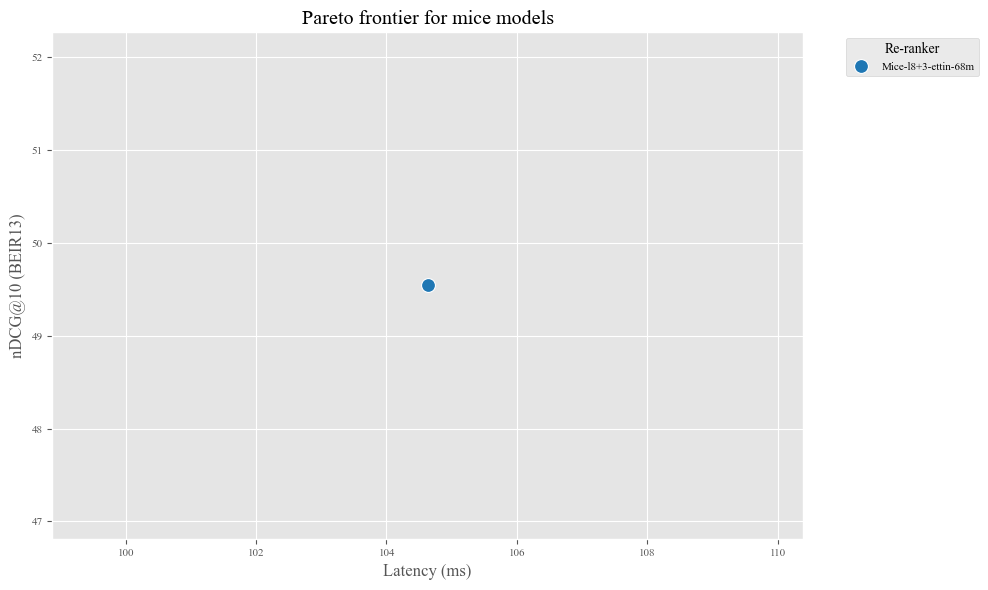

In [6]:
metric_key = "nDCG@10"
dataset_y = "minified"
dataset_y = "scifact"
dataset_y = "BEIR13"

bench_key = "mean_time"
labels, perfs, costs = [] , [] , []
#plot performance so see correlation between performance on minified and beir13
for model in benchmarked_models: 
    labels.append(model.name)
    perfs.append(model.results.loc[model.results["dataset"] == dataset_y, metric_key].item())
    costs.append(model.benchmark[bench_key] * 1e3) # ms

print(labels)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=costs,
    y=perfs,
    hue=labels,
    palette="tab10",
    s=100,
    ax=ax,
)
ax.set_xlabel(f"Latency (ms)")
ax.set_ylabel(f"{metric_key} ({dataset_y})")
ax.set_title(f"Pareto frontier for mice models")
plt.legend(title="Re-ranker", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"./local/figures/mice/Pareto_frontier.pdf")
plt.show()

# Analysis

## Distribution of ndcg for Mice-$\ell4$+3 v Mice-$\ell8$+3

In [ ]:
# Main table
import pandas as pd

xps = [
    "train_mice_miniLM_l4|8_ID_withruns",
    "baseline_small_CE_withruns",
    ]

dat_files = []
for xp in xps:
    xp_path = xps_root / xp
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    
    dat_files += list(xp_path.glob("results/models/*/evals/*.dat"))
    print(f"Using xp path: {xp_path}")
    xp_df = process_results(get_results(xp_path))

    datasets = xp_df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(xp_df['loss'].unique())}")
    # print(f"Backbones : {list(xp_df['base'].unique())}")
    display(xp_df.head())
# get dat files
print(f"got {len(dat_files)} runs")

In [ ]:

names_to_ignore = ["ettin"]
runs_per_model = {}

def parse_reranker_results(file_path_or_string):
    """
    Parses a reranker result file into a pandas DataFrame.
    The file is expected to have columns: Metric, QID, Score.
    """
    # Use sep='\s+' to handle multiple spaces or tabs
    # We define the column names manually as the file has no header
    df = pd.read_csv(
        file_path_or_string, 
        sep=r'\s+', 
        names=['Metric', 'QID', 'Score'], 
        header=None
    )
    return df

for dat in dat_files:
    model_name = dat.parent.parent.name
    dataset_name = re.match(r"detailed_(.+).dat", dat.name).group(1)
    runs = runs_per_model.get(model_name,{})
    runs[dataset_name] = parse_reranker_results(dat)
    runs_per_model[model_name] = runs

runs_per_model = {k:v for k,v in runs_per_model.items() if len(v.keys())}
models = list(runs_per_model.keys())



models = [
        model_name
        for model_name in models
        if not any([pattern in model_name for pattern in names_to_ignore])
    ]

datasets = list(runs_per_model[models[0]].keys())
print(f"got runs for models: {models}")
display(runs_per_model[models[0]]["trec2019"])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_comparison(runs_per_model, dataset, models):
    all_data = []

   
    # 1. Combine data
    for model_name in models:
        df = runs_per_model[model_name][dataset].copy()
        df["Model"] = model_name
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)

    # 2. Plotting with Deprecation Fixes
    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=combined_df,
        x="Model",
        y="Score",
        hue="Model",  # Fix: Assign x to hue
        col="Metric",
        kind="violin",
        inner="points",
        palette="viridis",
        legend=False,  # Fix: Remove redundant legend
        col_wrap=2,
        height=5,
        aspect=1.2,
        sharey=True,
    )

    # 4. Overlay Averages
    axes = g.axes.flatten()
    metrics = combined_df["Metric"].unique()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_data = combined_df[combined_df["Metric"] == metric]
        means = metric_data.groupby("Model", sort=False)["Score"].mean()

        for j, model_name in enumerate(models):
            avg_val = means[model_name]
            ax.text(
                j,
                avg_val,
                f"{avg_val:.3f}",
                color="black",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, lw=0),
            )

    g.set_axis_labels("", "Score Value")
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()


# Usage:
for dataset in datasets:
    print(f"distribution for {dataset}")
    plot_model_comparison(runs_per_model, dataset, models)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_all_lexical_dependencies(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Build a combined dataframe for all models
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Delta': df_model['Score'] - df_bm25['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Use lmplot for side-by-side regression analysis
    sns.set_theme(style="whitegrid")
    g = sns.lmplot(
        data=combined_df, 
        x='BM25 Score', 
        y='Delta', 
        col='Model', 
        hue='Model',
        palette='viridis',
        scatter_kws={'alpha': 0.4},
        line_kws={'lw': 2},
        height=5, 
        aspect=1.0,
        col_wrap=3
    )

    # 3. Add baseline and Correlation coefficients
    for model_name, ax in g.axes_dict.items():
        # Draw baseline at 0
        ax.axhline(0, color='black', linestyle='--', alpha=0.6)
        
        # Calculate correlation for this specific model
        subset = combined_df[combined_df['Model'] == model_name]
        # Drop NaNs if any exist to prevent correlation errors
        subset = subset.dropna(subset=['BM25 Score', 'Delta'])
        
        corr, _ = stats.pearsonr(subset['BM25 Score'], subset['Delta'])
        
        # Display correlation in the plot
        ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    g.set_axis_labels("BM25 Score (Lexical Signal)", "Gain (Model - BM25)")
    g.fig.suptitle(f'Reranker Gain vs Lexical Baseline Quality ({metric} - {dataset})', y=1.02, fontsize=16)
    
    plt.show()

# Execution
for dataset in datasets:
    plot_all_lexical_dependencies(runs_per_model, dataset, models)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bm25_vs_model_direct(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Get BM25 scores as the anchor
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Model Score': df_model['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Plotting
    g = sns.FacetGrid(combined_df, col="Model", hue="Model", 
                      palette='viridis', height=5, aspect=1, col_wrap=3)

    # Use regplot but disable the regression line if you just want the raw scatter, 
    # or keep it to see the general trend.
    g.map(sns.scatterplot, 'BM25 Score', 'Model Score', alpha=0.5)

    # 3. Add the Identity Line (y=x)
    for ax in g.axes.flatten():
        # Draw a 45-degree dashed line from (0,0) to (1,1)
        ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Identity (y=x)')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        
        # Optional: Count how many queries are above/below the line
        # This gives a quick "Win Rate" visual
        ax.fill_between([0, 1], [0, 1], 1, color='green', alpha=0.05) # "Model Win" zone
        ax.fill_between([0, 1], 0, [0, 1], color='red', alpha=0.05)   # "BM25 Win" zone

    g.set_axis_labels("BM25 Score", "Model Score")
    g.figure.suptitle(f'Performance Comparison on {dataset}: BM25 vs Rerankers ({metric})', y=1.05, fontsize=16)
    
    plt.tight_layout()
    plt.show()

# plot_bm25_vs_model_direct(runs_per_model, "trec2020", models)
# Execution
for dataset in datasets:
    plot_bm25_vs_model_direct(runs_per_model, dataset, models)

# Ablations

## Booleans Ablation

In [ ]:
# Main table
import pandas as pd
from IPython.display import display, HTML

xps = [
    "train_mice_miniLM_bools",
]


def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None


raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)


# Define regex patterns for tags
tags = {
    "base": r"base=(.*)_global",
    "global_cls_token": r"global_cls_token=(.*)_mask_cls_to_doc",
    "mask_query_to_cls": r"mask_query_to_cls=(.*)_loss",
    "mask_cls_to_doc": r"mask_cls_to_doc=(.*)_mask",
}

# rm row without "scorer" tag
df = df[df["scorer"].notna()]
# Split "scorer" into separate columns using the regex patterns
for tag_name, pattern in tags.items():
    df[tag_name] = df["scorer"].apply(lambda x: get_tag(x, pattern))


# Ensure the boolean columns are boolean type
bool_cols = ["global_cls_token", "mask_query_to_cls", "mask_cls_to_doc"]
for col in bool_cols:
    df[col] = df[col].map({"True": True, "False": False})

datasets = list(df["dataset"].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
# print(f"unique losses : {list(df["loss"].unique())}")
# print(f"Backbones : {list(df["base"].unique())}")


display(HTML(df.iloc[0:5].to_html()))

In [ ]:
# Plot in-domain nDCG@10_mean for each combination of boolean params

import matplotlib.pyplot as plt

for dataset in ["Mean In Domain", "mean"]:
    # Filter for in-domain dataset (assuming msmarco_dev is in-domain)
    in_domain_df = df[df["dataset"] == dataset].copy()

    # Group by the boolean combinations and compute mean of nDCG@10_mean and mean of nDCG@10_var
    grouped = (
        in_domain_df.groupby(bool_cols)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )

    # Compute std as sqrt of mean variance
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    # Create a combination label
    grouped["combination"] = grouped[bool_cols].astype(str).agg("_".join, axis=1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(data=grouped, x="combination", y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title("Mean nDCG@10 for Boolean Parameter Combinations (In-Domain)")
    ax.set_xlabel(
        "Parameter Combination (global_cls_token_mask_query_to_cls_mask_cls_to_doc)"
    )
    ax.set_ylabel("Mean nDCG@10")
    plt.xticks(rotation=45)
    plt.ylim(0.48, 0.68)
    plt.tight_layout()
    plt.show()

    # Display the grouped data
    display(grouped)

In [ ]:
# Plot impact of each boolean parameter separately

# Create subplots for each boolean parameter
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(
    "Impact of Each Boolean Parameter on Mean nDCG@10 ({dataset})".format(
        dataset=dataset
    )
)

grouped_dfs = []
for ax, param in zip(axes, bool_cols):
    grouped = (
        in_domain_df.groupby(param)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    sns.barplot(data=grouped, x=param, y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title(f"Impact of {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean nDCG@10")
    ax.set_ylim(0.48, 0.53)

    grouped_dfs.append(grouped)

plt.tight_layout()
plt.show()

## Mice MiniLM X+3 - Vanilla vs Inverted

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Inverted Cross-Self Attn",
    "train_mice_miniLM_lX+3_vanilla": "Vanilla Self-Cross Attn",
}


def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    xp_path = xps_root / xp / "20260425_161300" #
    if 'vanilla' in xp: 
        xp_path = get_last_xp(xps_root / xp)
    else:
        xp_path = xps_root / xp / "20260425_161300" #
        xp_path = get_last_xp(xps_root / xp)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

In [ ]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"

# Plot for each dataset
for dataset_name in ["Mean In Domain", "mean"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(8, 5))

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")

        ax.errorbar(
            grouped["n_contextualization_layers"],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=6,
            linewidth=2,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]} - {metric}"
        )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}_vs_vanilla.pdf")
    plt.show()
    # Display grouped results
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
        # display(grouped)